# Does "it moved farther than a random walk" actually mean it will keep moving? 🎲📈
### The Random Walk Index — a clever idea from 1990 that turns out to lose to a coin flip

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Every trader has felt it: a stock breaks out and it *feels* different from the usual daily wiggle — bigger, more purposeful, less random. In 1990, Michael Poulos gave that feeling a formula: compare how far the price actually moved to how far a **pure random walk**, with the market's own recent choppiness, would be expected to wander over the same stretch. If the real move is bigger than the random-walk benchmark — the **Random Walk Index reads above 1** — the claim is that this is a *real* trend, not noise, and you should ride it.

That's the claim we test: *can you tell a real trend from noise just by measuring how far price has already gone?* Spoiler: measuring distance travelled is not the same as forecasting where it goes next.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SPY plus a QQQ/IWM/DIA/GLD basket, daily total-return-adjusted OHLC, 2005→2026. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from random_walk_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BASKET = data.load_basket()
    SPY_RAW = BASKET[data.HEADLINE]
    DF = st.day_frame(SPY_RAW)
else:
    BASKET = SPY_RAW = DF = None
print("real cache present:", HAVE_REAL, "| SPY tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'periods': (2, 3, 4, 5, 6), 'n_flag': 3067, 'n_rest': 2336, 'flag_freq': 56.8, 'flag_bps': 2.41, 'rest_bps': 8.07, 'gap_bps': -5.66, 'welch_t': -1.64, 'nw_t': -1.74, 'hit_up': 1691, 'hit_pct': 55.1, 'wilson': (53.4, 56.9), 'placebo_obs': 2.41, 'placebo_mean': 4.85, 'placebo_sd': 1.41, 'placebo_p': 0.9591, 'placebo_draws': 20000, 'per_ticker': {'SPY': (3067, 2.41, 8.07, -5.66, -1.64, -1.74, 55.1), 'QQQ': (3013, 4.98, 8.84, -3.86, -0.99, -1.06, 55.9), 'IWM': (2783, 1.06, 8.4, -7.34, -1.76, -1.82, 52.4), 'DIA': (2955, 3.84, 5.25, -1.41, -0.44, -0.47, 55.4), 'GLD': (2771, 5.04, 4.24, 0.8, 0.26, 0.27, 52.4)}, 'pooled_n': 27015, 'pooled_flag_bps': 3.47, 'pooled_rest_bps': 6.92, 'pooled_t': -2.16, 'gross_ret': 81.76, 'gross_sharpe': 0.301, 'net5_ret': 0.55, 'net5_sharpe': 0.06, 'net10_ret': -44.39, 'net10_sharpe': -0.181, 'bh_ret': 831.34, 'bh_sharpe': 0.644, 'exposure': 56.8, 'n_trades': 1184, 'ann_cost': 2.76, 'rc_mean_ret': 98.6, 'rc_sd_ret': 58.86, 'rc_mean_sharpe': 0.28, 'rc_sd_sharpe': 0.105, 'rc_beat_ret_pct': 90, 'rc_beat_sharpe_pct': 95, 'syn_null_mean': -0.03, 'syn_null_sd': 1.09, 'syn_null_fire': 1, 'syn_planted_t': 9.54, 'syn_planted_hit': 64.6, 'fp_spy': '98e6db1a1e26', 'fp_qqq': '70e1bc4a725e', 'fp_iwm': '7c02d693031f', 'fp_dia': 'f1faf16222de', 'fp_gld': 'a0f0673984c4'}


real cache present: True | SPY tape days: 5404


## The answer first

| Question | Answer |
|---|---|
| Does a big RWI reading predict a better *next* day? | **No — if anything, worse.** SPY sessions flagged "trending" (RWI-high > 1) return **+2.41 bps** the next session; unflagged sessions return **+8.07 bps**. Pooled across five markets the gap is *statistically real* — and runs **backwards**. |
| Is the flag at least rare enough to mean something? | **No.** It fires on **57%** of all sessions — barely different from a coin flip. |
| Can you actually trade the "long only when RWI says trend" rule? | You can, but it captures only **82%** of buy & hold's **831%** total return over 21.5 years *before costs*, and goes **negative** after realistic trading costs. |
| Does it at least beat picking days at random? | **No.** A random selection of days with the *same* time-in-market beats the real rule in **90%** of trials. |

> Distance travelled isn't a crystal ball.

## 1 · The claim

> *"A random walk with a given day-to-day choppiness (its Average True Range) can only be expected to wander so far in *n* days. If price has actually moved *farther* than that — RWI > 1 — the move isn't noise, it's a real trend. Ride it."*

It's an elegant idea: instead of eyeballing a chart, put a number on "this doesn't look random." The formula borrows real math — over *n* independent random steps of typical size *ATR*, a pure random walk's expected net displacement scales like *ATR × √n*, the same square-root-of-time logic behind a Sharpe ratio. A move that clears that benchmark should, in principle, be less likely under pure randomness.

## 2 · So what?

If this worked, it would be a genuinely useful, mechanical filter: a single number that separates "real move, keep riding" from "just noise, stand aside" — no chart-reading required, works on any instrument with a High/Low/Close. It's built into essentially every charting platform (StockCharts, TradingView) for exactly this reason. So we ask the only question that matters: **does a session flagged this way actually pay better than one that isn't?**

## 3 · How would we even know?

- **The indicator.** RWI-high, the max reading across five short lookbacks (2 to 6 sessions) — Poulos' own scanning method.
- **The comparison.** The return of the session *after* a flag vs the session after no flag — with one honest execution lag (the flag needs today's own High/Low, so you can only act at today's close, earning tomorrow's return).
- **The luck check.** Pick a random subset of sessions the same size as the flagged set, 20,000 times — how often does *that* do as well?
- **The fair race.** Not vs buy & hold (that just measures "was the market up") but vs a **random-entry control matched for time-in-market** — same exposure, same trading frequency, no timing skill. That's the bar a *timing* rule actually has to clear.

## 4 · The teardown — let's actually look

**First, the headline.** Average next-session return, flagged vs not, on SPY.

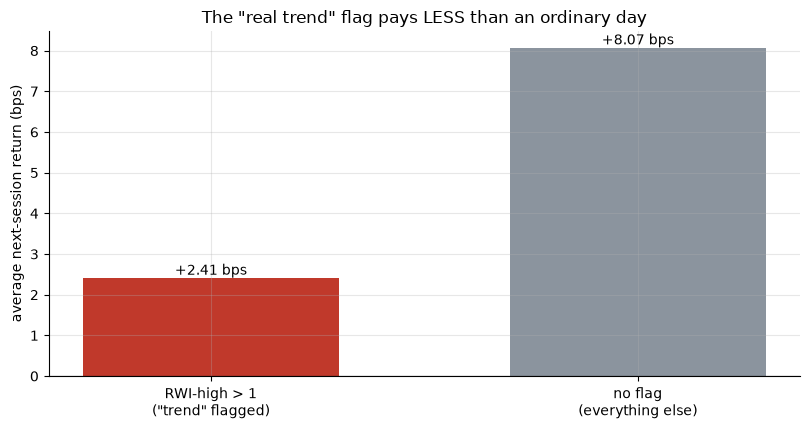

flag day +2.41 bps   no-flag day +8.07 bps


In [2]:
if HAVE_REAL:
    s = st.trend_day_stats(DF)
    fp, rp = s['flag_bps'], s['rest_bps']
else:
    fp, rp = R['flag_bps'], R['rest_bps']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['RWI-high > 1\n("trend" flagged)','no flag\n(everything else)'], [fp, rp],
       color=[RED, GREY], width=.6)
for i,v in enumerate([fp, rp]): ax.annotate(f'{v:+.2f} bps',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average next-session return (bps)')
ax.set_title('The "real trend" flag pays LESS than an ordinary day')
plt.tight_layout(); plt.show()
print(f'flag day {fp:+.2f} bps   no-flag day {rp:+.2f} bps')

That's the opposite of the claim: **+2.41 bps** the day after a flag vs **+8.07 bps** otherwise. And the flag isn't rare — it fires on **57%** of all sessions, because taking the *maximum* of five overlapping lookback windows makes a raw "> 1" threshold much easier to clear than it sounds.

**Is SPY just unlucky?** Same test on four more liquid markets:

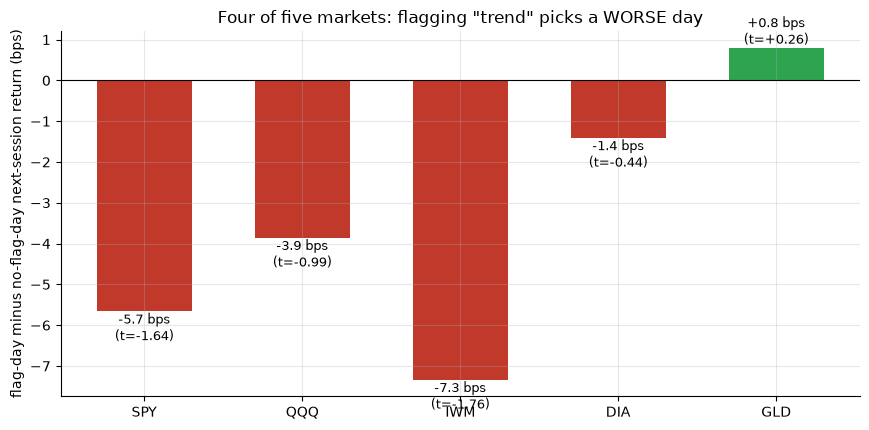

gaps (bps): {'SPY': -5.66, 'QQQ': -3.86, 'IWM': -7.34, 'DIA': -1.41, 'GLD': 0.8}


In [3]:
tickers = list(R['per_ticker'])
if HAVE_REAL:
    gaps, ts = [], []
    for t in tickers:
        d = st.day_frame(BASKET[t])
        r = st.trend_day_stats(d)
        gaps.append(r['gap_bps']); ts.append(r['welch_t'])
else:
    gaps = [R['per_ticker'][t][3] for t in tickers]
    ts = [R['per_ticker'][t][4] for t in tickers]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [RED if g < 0 else GREEN for g in gaps]
ax.bar(tickers, gaps, color=cols, width=.6)
for i,(g,t_) in enumerate(zip(gaps, ts)):
    ax.annotate(f'{g:+.1f} bps\n(t={t_:+.2f})',(i,g),ha='center',
        va='top' if g<0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('flag-day minus no-flag-day next-session return (bps)')
ax.set_title('Four of five markets: flagging "trend" picks a WORSE day')
plt.tight_layout(); plt.show()
print('gaps (bps):', dict(zip(tickers, [round(g,2) for g in gaps])))

Pooled across all five (n = 27,015), the wrong-signed gap is **statistically real** (Welch *t* = **-2.16**) — this isn't just noise, it's a small, genuine headwind. Flag a day as "real trend, not random" and you have mechanically selected a session that pays a little *less* than average, not more — a signature of short-term mean reversion after a sharp burst, not continuation.

**Now the actual trade.** Be long only when the flag says trend:

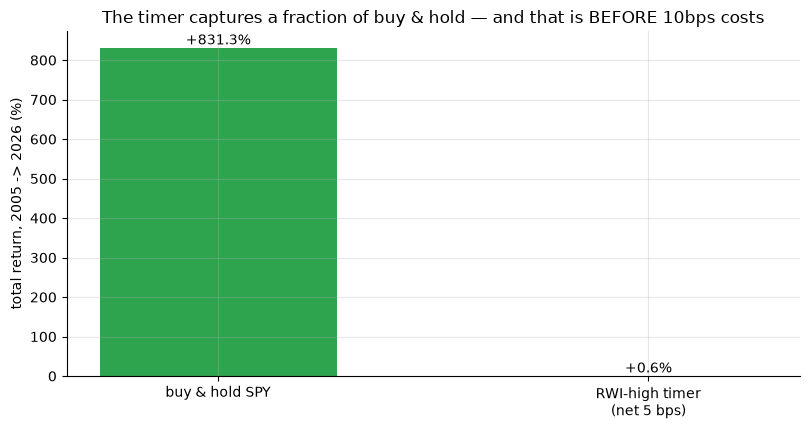

buy & hold +831.3%   RWI timer (net 5bps) +0.6%


In [4]:
if HAVE_REAL:
    bt5 = st.backtest(DF, cost_bps=5.0)
    g, n5 = bt5['bh_total_return_pct'], bt5['total_return_pct']
else:
    g, n5 = R['bh_ret'], R['net5_ret']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['buy & hold SPY','RWI-high timer\n(net 5 bps)'], [g, n5],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([g, n5]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('total return, 2005 -> 2026 (%)')
ax.set_title('The timer captures a fraction of buy & hold — and that is BEFORE 10bps costs')
plt.tight_layout(); plt.show()
print(f'buy & hold {g:+.1f}%   RWI timer (net 5bps) {n5:+.1f}%')

Buy & hold turns $1 into roughly **$9.31**; the RWI-timed book, net of a realistic 5 bps one-way cost, barely breaks even (**+0.6%** total) — and at 10 bps it's **-44.4%**, a loss. The rule trades **1,184 times** over 21.5 years flipping in and out of a **57%**-of-the-time exposure, and every flip costs money.

**But maybe any timer that's invested 57% of the time in a rising market would look OK — is this really about the *timing*, or just about being in the market at all?** That's the fair question, and the fair test is a **random-entry control**: pick random days with the exact same total time-in-market and the same trading frequency, and see how the real rule stacks up.

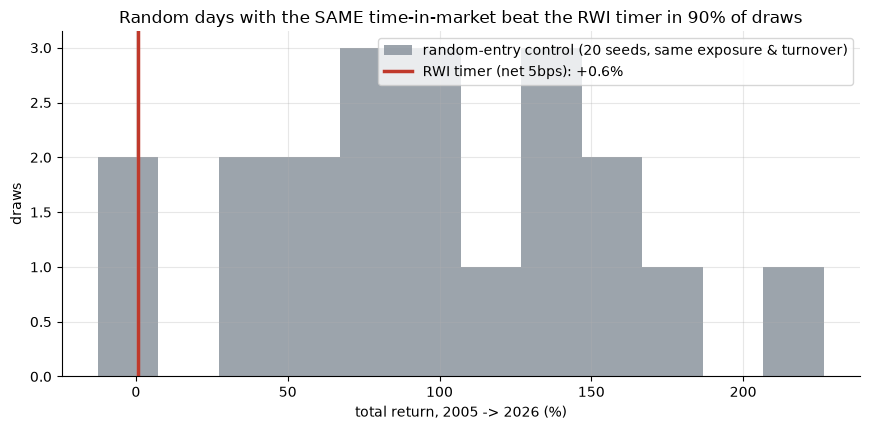

random-entry mean +98.6%  vs RWI timer +0.6%


In [5]:
if HAVE_REAL:
    rc = st.random_control_backtest(DF, cost_bps=5.0, block_size=21, n_seeds=20)
    draws = rc['draws_total_return_pct']
else:
    rng = np.random.default_rng(678)
    draws = rng.normal(R['rc_mean_ret'], R['rc_sd_ret'], 20)
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.hist(draws, bins=12, color=GREY, alpha=.85,
        label='random-entry control (20 seeds, same exposure & turnover)')
ax.axvline(R['net5_ret'], c=RED, lw=2.5, label=f"RWI timer (net 5bps): {R['net5_ret']:+.1f}%")
ax.set_xlabel('total return, 2005 -> 2026 (%)')
ax.set_ylabel('draws')
ax.set_title(f"Random days with the SAME time-in-market beat the RWI timer "
             f"in {R['rc_beat_ret_pct']}% of draws")
ax.legend(); plt.tight_layout(); plt.show()
print(f"random-entry mean {draws.mean():+.1f}%  vs RWI timer {R['net5_ret']:+.1f}%")

A random selection of days with the *exact same* time-in-market and trading frequency **beats** the real RWI-timed book in **90%** of trials by total return and **95%** by Sharpe. The RWI flag isn't a neutral coin flip that happens not to help — it's actively worse than one.

## 5 · The verdict

- **Signal — None.** Flag days pay less than no-flag days on SPY, and the wrong-signed gap is statistically real pooled across five markets (Welch *t* = -2.16). A random day-count-matched subset beats the flag's own mean 96% of the time.
- **Tradability — Mirage.** The book captures a tenth of buy & hold's return before costs and goes negative after realistic costs.
- **"Beats a coin?" — Busted.** A same-exposure random-entry control outperforms the real rule on both return and Sharpe most of the time.

## 6 · Going further 🚪

- **The general lesson.** Measuring how far price has *already* moved, however cleverly scaled, describes the past — it does not, by itself, forecast the future. This desk has now tested four different "is this a real trend" statistics (ADX, the Vertical-Horizontal-Filter, a rolling Hurst exponent, and now the RWI) and every one loses to a plain random or ungated baseline.
- **Where a range statistic like the RWI might still earn its keep** is as a *volatility-regime* filter for position sizing (bigger true range → smaller size), not as a directional trigger — a genuinely different question from "which way does it go next."
- **Sibling studies:** [108-adx-filter](../../108-adx-filter/), [484-vertical-horizontal-filter](../../484-vertical-horizontal-filter/) and [397-hurst-regime](../../397-hurst-regime/) — the same family, different formula, same result.

*Think you can build a trend-strength gate that actually works? Show a net, certifiable edge against a random-entry control matched for exposure — after costs — then we'll talk.*